In [1]:
cols = [
    "loan_amnt",
    "int_rate",
    "installment",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "annual_inc",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "gdp_growth_t1",
    "unemployment_rate_t1",
    "fedfunds_t1",
    "inflation_t1",
    "housing_price_t1",
]

In [2]:
import pandas as pd

df = pd.read_csv('rebalanced_age_data_two.csv')
df = df.dropna(subset=cols)

/var/folders/bm/0wq19v017y79n8fk7_72tt4c0000gn/T/ipykernel_16313/3341669861.py:3: DtypeWarning: Columns (19,49,59,118,129,130,131,134,135,136,139) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('rebalanced_age_data_two.csv')


In [3]:
nan_count = df[cols].isnull().sum()
print(nan_count)

loan_amnt               0
int_rate                0
installment             0
pub_rec                 0
revol_bal               0
revol_util              0
total_acc               0
annual_inc              0
delinq_2yrs             0
inq_last_6mths          0
open_acc                0
gdp_growth_t1           0
unemployment_rate_t1    0
fedfunds_t1             0
inflation_t1            0
housing_price_t1        0
dtype: int64


In [4]:
from sklearn.preprocessing import KBinsDiscretizer

n_bins = 3  # Number of bins you want to create

# Initialize the discretizer; you can choose 'uniform' for equal-width,
# 'quantile' for equal-frequency, or 'kmeans' for clustering-based discretization.
kbd = KBinsDiscretizer(n_bins=n_bins,encode='ordinal', strategy='kmeans')

# Assuming df contains only the columns you want to discretize (or select them)
df_subset = df[cols].copy()
df_subset_discretized = pd.DataFrame(
    kbd.fit_transform(df_subset),
    columns=[col + '_disc' for col in cols]
)

# Merge the discretized columns back to the original DataFrame if needed
df = pd.concat([df, df_subset_discretized], axis=1)

print(df.head())

           id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  68407277.0        NaN     3600.0       3600.0           3600.0   36 months   
1  68338832.0        NaN     1400.0       1400.0           1400.0   36 months   
2  68436666.0        NaN     5000.0       5000.0           5000.0   36 months   
3  67849662.0        NaN     4225.0       4225.0           4225.0   36 months   
4  68387134.0        NaN     2500.0       2500.0           2500.0   36 months   

   int_rate  installment grade sub_grade  ... total_acc_disc annual_inc_disc  \
0     13.99       123.03     C        C4  ...            0.0             0.0   
1     12.88        47.10     C        C2  ...            1.0             0.0   
2     13.44       169.54     C        C3  ...            0.0             0.0   
3     14.85       146.16     C        C5  ...            0.0             0.0   
4     17.27        89.47     D        D3  ...            1.0             0.0   

  delinq_2yrs_disc  inq_last_6mt

inq_last_6mths_disc
0.0    153688
1.0     30077
2.0       128
Name: count, dtype: int64


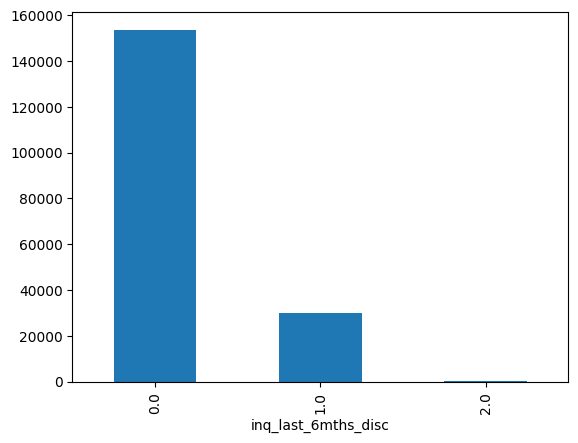

In [5]:
import matplotlib.pyplot as plt
df["inq_last_6mths_disc"].value_counts().sort_index().plot(kind='bar')
print(df["inq_last_6mths_disc"].value_counts())

In [6]:
cols = [
    "loan_amnt_disc",
    "int_rate_disc",
    "installment_disc",
    "pub_rec_disc",
    "revol_bal_disc",
    "revol_util_disc",
    "total_acc_disc",
    "annual_inc_disc",
    "delinq_2yrs_disc",
    "inq_last_6mths_disc",
    "open_acc_disc",
    "gdp_growth_t1_disc",
    "unemployment_rate_t1_disc",
    "fedfunds_t1_disc",
    "inflation_t1_disc",
    "housing_price_t1_disc",
    "grade",
    "sub_grade",
    "emp_length",
    "home_ownership",
    "purpose",
    "fico_bucket_pct",
    "default_indicator",
    "age_group",
    "issue_quarter",
]

In [7]:
df = df[cols]

In [8]:
df.to_csv('rebalanced_age_data_discretized_two.csv', index=False)